In [20]:
import os
from pathlib import Path
import torch
import json, random
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, set_seed, Trainer, TrainingArguments
from peft import LoraConfig, TaskType, get_peft_model, prepare_model_for_kbit_training, PeftModel
from dataclasses import dataclass
from typing import Any
from datasets import Dataset
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch

#参数设置
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["MODELSCOPE_CACHE"] = "/data0/modelscope/AI-ModelScope"

MODEL_PATH = "/data0/modelscope/qwen3/models/Qwen/Qwen3-32B"
DATA_ROOT = Path("/home/hushengchun/project/BTOM-transformerlens/data")

DATASETS = ("scat_targeted","dual_scat")  # 或 ("dual_scat",) / 两套一起
if os.environ.get("FT_DATASETS"):
    DATASETS = tuple(s.strip() for s in os.environ["FT_DATASETS"].split(",") if s.strip())

OUTPUT_DIR = Path(os.environ.get(
    "FT_OUTPUT_DIR", f"/data0/hushengchun/qwen3-32b-lora-{'-'.join(DATASETS)}"
))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

N_TRAIN = None          # None = 全部 train
N_EVAL = None           # None = 全部 test
SEED = 42
MAX_SEQ_LEN = 2048

LORA_R, LORA_ALPHA, LORA_DROPOUT = 16, 32, 0.05
LORA_TARGETS = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]

NUM_EPOCHS = 1
PER_DEVICE_BATCH = 1
GRAD_ACCUM = 8
LR = 2e-4
WARMUP_RATIO = 0.03
LOGGING_STEPS, SAVE_STEPS, EVAL_STEPS = 10, 200, 200
USE_4BIT = True
set_seed(SEED)
DTYPE = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float16
quant = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True, bnb_4bit_compute_dtype=DTYPE,
) if USE_4BIT else None

In [22]:
#加载分词器
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_PATH, trust_remote_code=True, local_files_only=True, use_fast=False
)
tokenizer.pad_token = tokenizer.pad_token or tokenizer.eos_token
tokenizer.padding_side = "right"

CHAT_KW = {}
try:
    tokenizer.apply_chat_template(
        [{"role": "user", "content": "hi"}], tokenize=False, add_generation_prompt=True, enable_thinking=False
    )
    CHAT_KW["enable_thinking"] = False
except TypeError:
    pass

In [ ]:
#加载模型
model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH, quantization_config=quant, device_map="auto", torch_dtype=DTYPE,
    trust_remote_code=True, local_files_only=True, low_cpu_mem_usage=True,
)
model.config.use_cache = False
if USE_4BIT:
    model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)
else:
    model.gradient_checkpointing_enable()

model = get_peft_model(model, LoraConfig(
    task_type=TaskType.CAUSAL_LM, r=LORA_R, lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT, bias="none", target_modules=LORA_TARGETS,
))
model.print_trainable_parameters()

In [ ]:
#prompt
SEP = 10
SYSTEM_PROMPT = """You solve a three-candidate grid puzzle.

Each puzzle has one hidden rule shared by all of its examples. Every example shows:
- three 3x3 candidate grids (A, B, C)
- a smaller query grid
- for the three training examples, the correct output grid

How to solve:
1. Compare the query with A/B/C and decide which candidate matches.
2. From the winning candidate, extract a small value grid using the same rule as the examples.
3. Emit only that value grid. Cells are colors 0-9.

Color ids: 0 black, 1 blue, 2 red, 3 green, 4 yellow, 5 grey, 6 pink, 7 orange, 8 teal, 9 maroon.
Color 10 is a canvas separator/padding only. It never appears in candidates, query, or the answer. Never copy 10.

Reply with the test output grid alone: one row per line, integers separated by a single space. No labels, no candidate letter, no explanation."""


def grid_to_text(grid) -> str:
    return "\n".join(" ".join(str(int(v)) for v in row) for row in grid)


def parse_grid(text: str):
    rows = []
    for line in text.strip().splitlines():
        line = line.strip().replace(",", " ")
        if not line:
            if rows:
                break
            continue
        parts = line.split()
        if not parts or not all(p.lstrip("-").isdigit() for p in parts):
            if rows:
                break
            continue
        rows.append([int(p) for p in parts])
    return rows


def looks_like_grid(rows) -> bool:
    if not rows or not rows[0]:
        return False
    w = len(rows[0])
    return w > 0 and all(len(r) == w for r in rows) and all(0 <= v <= 9 for r in rows for v in r)


def _trim_query(block):
    rows = [list(map(int, row)) for row in block]
    while rows and all(v == SEP for v in rows[0]):
        rows.pop(0)
    while rows and all(v == SEP for v in rows[-1]):
        rows.pop()
    cols = list(zip(*rows)) if rows else []
    while cols and all(v == SEP for v in cols[0]):
        cols.pop(0)
    while cols and all(v == SEP for v in cols[-1]):
        cols.pop()
    return [list(row) for row in zip(*cols)] if cols else rows


def split_canvas(grid):
    arr = [list(map(int, row)) for row in grid]
    n_rows, n_cols = len(arr), (len(arr[0]) if arr else 0)
    seps = [c for c in range(n_cols) if all(arr[r][c] == SEP for r in range(n_rows))]
    blocks, start = [], 0
    for c in seps + [n_cols]:
        if c > start:
            blocks.append([row[start:c] for row in arr])
        start = c + 1
    if len(blocks) >= 4:
        return blocks[:3], _trim_query(blocks[3])
    return None, None


def format_panels(grid) -> str:
    cands, query = split_canvas(grid)
    if cands is None:
        raise ValueError("canvas 无法拆成 3 候选 + query")
    parts = [f"Candidate {n}:\n{grid_to_text(g)}" for n, g in zip("ABC", cands)]
    parts.append(f"Query:\n{grid_to_text(query)}")
    return "\n\n".join(parts)


def format_block(title, inp, output=None) -> str:
    body = f"{title}\n{format_panels(inp)}"
    if output is None:
        return body + "\n\nOutput:"
    return body + f"\n\nOutput:\n{grid_to_text(output)}"


def task_to_messages(task: dict, test_output, source: str = "", task_id: str = "") -> dict:
    chunks = [format_block(f"Example {i}", ex["input"], ex["output"]) for i, ex in enumerate(task["train"], 1)]
    chunks.append(format_block("Test", task["test"][0]["input"]))
    return {
        "source": source,
        "task_id": task_id,
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": "\n\n".join(chunks)},
            {"role": "assistant", "content": grid_to_text(test_output)},
        ],
    }


def load_split(name: str, split: str) -> list[dict]:
    folder = DATA_ROOT / name
    challenges = json.loads((folder / f"{split}_challenges.json").read_text())
    solutions = json.loads((folder / f"{split}_solutions.json").read_text())
    rows = []
    for tid, task in challenges.items():
        if tid not in solutions:
            continue
        try:
            rows.append(task_to_messages(task, solutions[tid][0], source=name, task_id=tid))
        except (ValueError, IndexError, TypeError) as e:
            print(f"[skip] {name}/{split}/{tid}: {e}")
    return rows


train_rows, eval_rows = [], []
for name in DATASETS:
    tr, ev = load_split(name, "train"), load_split(name, "test")
    print(f"{name}: train={len(tr)} test={len(ev)}")
    train_rows.extend(tr)
    eval_rows.extend(ev)

rng = random.Random(SEED)
rng.shuffle(train_rows)
rng.shuffle(eval_rows)
if N_TRAIN is not None:
    train_rows = train_rows[:N_TRAIN]
if N_EVAL is not None:
    eval_rows = eval_rows[:N_EVAL]
print(f"total train={len(train_rows)} eval={len(eval_rows)}")
print("===== USER (sample) =====\n", train_rows[0]["messages"][1]["content"][:500], "\n===== GOLD =====\n", train_rows[0]["messages"][2]["content"])


scat_targeted: train=3000 test=2000
dual_scat: train=3000 test=2000
total train=6000 eval=4000
===== USER (sample) =====
 Example 1
Candidate A:
1 5 3
4 0 5
6 5 0

Candidate B:
3 5 0
5 0 3
3 5 3

Candidate C:
3 3 4
0 3 4
0 0 3

Query:
3
5
5

Output:
3 3

Example 2
Candidate A:
4 4 4
8 4 3
0 7 0

Candidate B:
0 0 7
0 4 4
7 7 7

Candidate C:
4 3 3
4 3 3
3 3 4

Query:
4
4
3

Output:
3 4

Example 3
Candidate A:
3 3 2
2 3 1
3 2 1

Candidate B:
3 0 4
0 5 4
1 5 0

Candidate C:
7 3 0
2 5 2
6 2 7

Query:
3
2
2

Output:
3 1

Test
Candidate A:
8 6 7
8 7 0
3 9 0

Candidate B:
1 0 5
8 0 5
0 8 0

Candidate C:
8 0 6
6 0 6
6 7 8

 
===== GOLD =====
 6 8


In [ ]:
def encode_example(example):
    msgs = example["messages"]
    prompt = tokenizer.apply_chat_template(msgs[:-1], tokenize=False, add_generation_prompt=True, **CHAT_KW)
    full = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=False, **CHAT_KW)
    prompt_ids = tokenizer(prompt, add_special_tokens=False)["input_ids"]
    tok = tokenizer(full, add_special_tokens=False, truncation=True, max_length=MAX_SEQ_LEN)
    ids = tok["input_ids"]
    n = min(len(prompt_ids), len(ids))
    return {"input_ids": ids, "attention_mask": tok["attention_mask"], "labels": [-100] * n + ids[n:]}


def to_hf(rows):
    ds = Dataset.from_list(rows)
    return ds.map(encode_example, remove_columns=ds.column_names)


train_ds, eval_ds = to_hf(train_rows), to_hf(eval_rows)
assert sum(x != -100 for x in train_ds[0]["labels"]) > 0
print(train_ds, "seq", len(train_ds[0]["input_ids"]), "supervised", sum(x != -100 for x in train_ds[0]["labels"]))


@dataclass
class PadCollator:
    pad_id: int
    def __call__(self, features: list[dict[str, Any]]) -> dict[str, torch.Tensor]:
        m = max(len(f["input_ids"]) for f in features)
        out = {"input_ids": [], "attention_mask": [], "labels": []}
        for f in features:
            p = m - len(f["input_ids"])
            out["input_ids"].append(f["input_ids"] + [self.pad_id] * p)
            out["attention_mask"].append(f["attention_mask"] + [0] * p)
            out["labels"].append(f["labels"] + [-100] * p)
        return {k: torch.tensor(v) for k, v in out.items()}


arg_kwargs = dict(
    output_dir=str(OUTPUT_DIR), num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=PER_DEVICE_BATCH, per_device_eval_batch_size=PER_DEVICE_BATCH,
    gradient_accumulation_steps=GRAD_ACCUM, learning_rate=LR, warmup_ratio=WARMUP_RATIO,
    lr_scheduler_type="cosine", logging_steps=LOGGING_STEPS, save_steps=SAVE_STEPS,
    save_total_limit=2, bf16=DTYPE == torch.bfloat16, fp16=DTYPE != torch.bfloat16,
    gradient_checkpointing=True, optim="paged_adamw_8bit" if USE_4BIT else "adamw_torch",
    report_to=[], remove_unused_columns=False, dataloader_num_workers=2,
    max_grad_norm=1.0, seed=SEED,
)
try:
    args = TrainingArguments(eval_strategy="steps", eval_steps=EVAL_STEPS, **arg_kwargs)
except TypeError:
    args = TrainingArguments(evaluation_strategy="steps", eval_steps=EVAL_STEPS, **arg_kwargs)

trainer = Trainer(model=model, args=args, train_dataset=train_ds, eval_dataset=eval_ds, data_collator=PadCollator(tokenizer.pad_token_id))
trainer


In [ ]:
train_result = trainer.train()
print(train_result.metrics)
adapter_dir = OUTPUT_DIR / "adapter"
trainer.save_model(str(adapter_dir))
tokenizer.save_pretrained(str(adapter_dir))
print("saved", adapter_dir)


In [ ]:
model.eval()
probe = eval_rows[0]["messages"]
text = tokenizer.apply_chat_template(probe[:-1], tokenize=False, add_generation_prompt=True, **CHAT_KW)
inputs = tokenizer(text, return_tensors="pt").to(model.device)
with torch.no_grad():
    out = model.generate(**inputs, max_new_tokens=64, do_sample=False, pad_token_id=tokenizer.pad_token_id)
pred = tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
print(pred, "\n--- gold ---\n", probe[-1]["content"])
print("exact", parse_grid(pred) == parse_grid(probe[-1]["content"]))


In [39]:
#加载模型（基座、微调）
# @skip_train
# "lora"：磁盘 adapter；"base"：微调前基座；"session"：当前 notebook 里刚训完的 model
EVAL_WHICH = "lora"
EVAL_DATASET = DATASETS[0]
EVAL_SPLIT = "test"          # "test" / "test_new"
EVAL_ADAPTER = Path(f"/data0/hushengchun/qwen3-32b-lora-{EVAL_DATASET}/adapter")
EVAL_BATCH, EVAL_MAX_NEW = 4, 64

items = load_split(EVAL_DATASET, EVAL_SPLIT)


def _eval_quant():
    if not USE_4BIT:
        return None
    return BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=DTYPE,
    )


def _load_base():
    return AutoModelForCausalLM.from_pretrained(
        MODEL_PATH, quantization_config=_eval_quant(), device_map="auto", torch_dtype=DTYPE,
        trust_remote_code=True, local_files_only=True, low_cpu_mem_usage=True, attn_implementation="eager",
        output_hidden_states=True, 
    )


if EVAL_WHICH == "session":
    eval_model = model.eval()
elif EVAL_WHICH == "base":
    eval_model = _load_base().eval()
elif EVAL_WHICH == "lora":
    eval_model = PeftModel.from_pretrained(_load_base(), str(EVAL_ADAPTER)).eval()
else:
    raise ValueError("EVAL_WHICH 只能是 'lora' / 'base' / 'session'")

The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading checkpoint shards:   0%|          | 0/17 [00:00<?, ?it/s]

In [40]:
#模型评测
EVAL_N = 200  # 只测前 N 条；None 或 0 = 全部。改完直接重跑本格即可，不必重载模型
eval_items = items[:EVAL_N] if EVAL_N else items
out_json = EVAL_ADAPTER.parent / (
    f"{EVAL_SPLIT}_{EVAL_WHICH}_n{EVAL_N}_metrics.json" if EVAL_N else f"{EVAL_SPLIT}_{EVAL_WHICH}_metrics.json"
)
print(f"eval {EVAL_DATASET}/{EVAL_SPLIT} which={EVAL_WHICH} n={len(eval_items)}/{len(items)} -> {out_json}")

pad_side = tokenizer.padding_side
tokenizer.padding_side = "left"
prompts = [tokenizer.apply_chat_template(r["messages"][:-1], tokenize=False, add_generation_prompt=True, **CHAT_KW) for r in eval_items]
golds = [parse_grid(r["messages"][-1]["content"]) for r in eval_items]

n_exact = n_fmt = n_done = 0
records = []
for i in range(0, len(prompts), EVAL_BATCH):
    batch_p, batch_g = prompts[i:i + EVAL_BATCH], golds[i:i + EVAL_BATCH]
    enc = tokenizer(batch_p, return_tensors="pt", padding=True, add_special_tokens=False)
    enc = {k: v.to(eval_model.device) for k, v in enc.items()}
    with torch.no_grad():
        gen = eval_model.generate(**enc, max_new_tokens=EVAL_MAX_NEW, do_sample=False, pad_token_id=tokenizer.pad_token_id)
    plen = enc["input_ids"].shape[1]
    for j, seq in enumerate(gen):
        raw = tokenizer.decode(seq[plen:], skip_special_tokens=True)
        pred = parse_grid(raw)
        exact, fmt = pred == batch_g[j], looks_like_grid(pred)
        n_exact += int(exact); n_fmt += int(fmt); n_done += 1
        row = eval_items[i + j]
        records.append({
            "i": i + j, "task_id": row.get("task_id"), "exact": exact, "format_ok": fmt,
            "pred": pred, "gold": batch_g[j], "raw": raw[:200],
        })
    if n_done % 50 < EVAL_BATCH or n_done == len(prompts):
        print(f"[{n_done}/{len(prompts)}] exact={n_exact/n_done:.4f} format={n_fmt/n_done:.4f}")

metrics = {
    "which": EVAL_WHICH, "dataset": EVAL_DATASET, "split": EVAL_SPLIT,
    "n": n_done, "n_total": len(items), "limit": EVAL_N,
    "exact": n_exact, "exact_acc": n_exact / n_done, "format_ok": n_fmt, "format_acc": n_fmt / n_done,
}
out_json.write_text(json.dumps({"metrics": metrics, "records": records}, ensure_ascii=False, indent=2))
print("FINAL", metrics)
tokenizer.padding_side = pad_side


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


eval scat_targeted/test which=lora n=200/2000 -> /data0/hushengchun/qwen3-32b-lora-scat_targeted/test_lora_n200_metrics.json


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p'

[52/200] exact=0.9231 format=1.0000


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p'

[100/200] exact=0.9400 format=1.0000


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p'

[152/200] exact=0.9539 format=1.0000


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p'

[200/200] exact=0.9600 format=1.0000
FINAL {'which': 'lora', 'dataset': 'scat_targeted', 'split': 'test', 'n': 200, 'n_total': 2000, 'limit': 200, 'exact': 192, 'exact_acc': 0.96, 'format_ok': 200, 'format_acc': 1.0}


In [41]:
# 卸掉评测模型，腾出显存后再换 EVAL_WHICH 重跑加载格
import gc

for _name in ("eval_model",):
    if _name in globals():
        del globals()[_name]

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    torch.cuda.synchronize()
    free, total = torch.cuda.mem_get_info()
    print(f"cuda used {(total - free) / 1024**3:.2f} / {total / 1024**3:.2f} GB")
else:
    print("no cuda")

cuda used 30.32 / 79.25 GB


scat_targeted test move_to_match_0001


TypeError: A single argument passed to legend() must be a list of labels, but found an Artist in there.

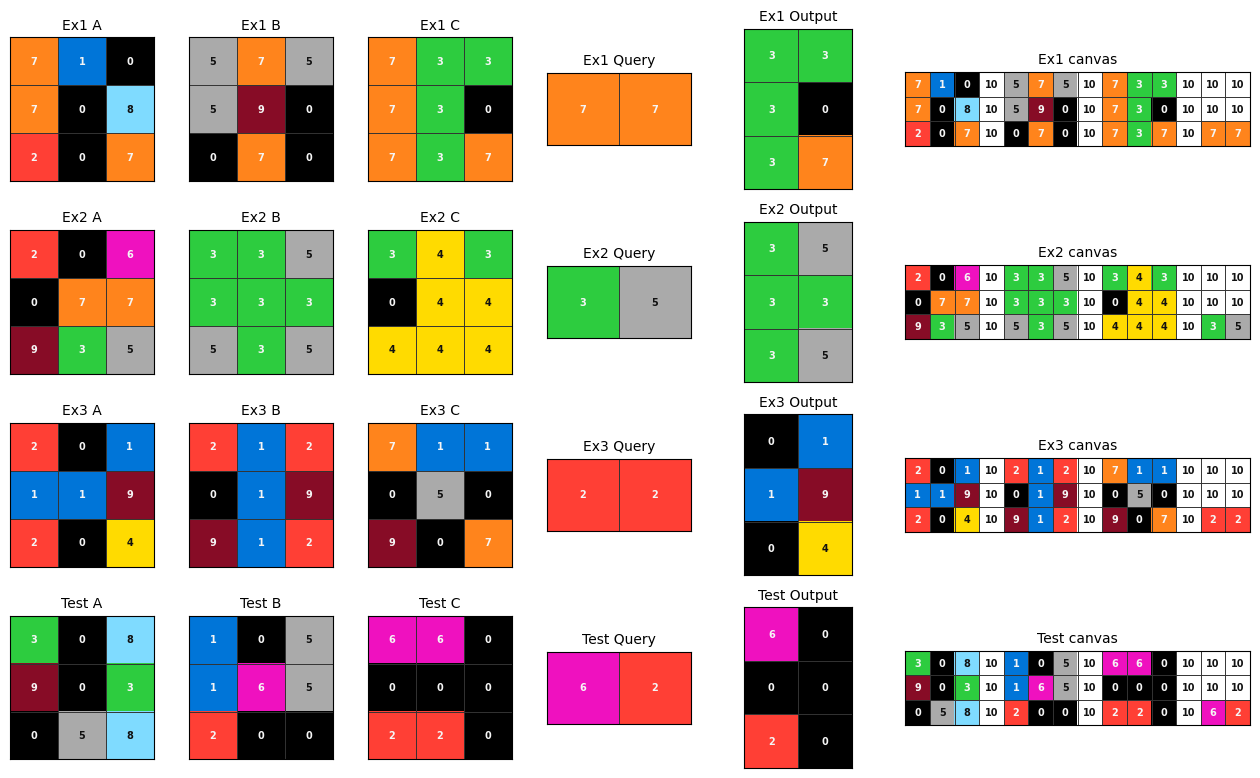

In [ ]:
# @skip_train
from export_mtm_csv import iter_viz_tasks, split_canvas

VIS_PATH = Path("/home/hushengchun/project/BTOM-transformerlens/data_uniform/scat_targeted.jsonl")
# 旧 challenges JSON 仍可用，例如：DATA_ROOT / VIS_DATASET / f"{VIS_SPLIT}_challenges.json"
VIS_DATASET, VIS_SPLIT, VIS_INDEX = "scat_targeted", "test", 1
VIS_TASK_ID = None
SHOW_CELL_IDS = True

COLOR_NAMES = ["black","blue","red","green","yellow","grey","pink","orange","teal","maroon","white"]
COLOR_RGB = {
    "black":(0,0,0), "blue":(0.00,0.46,0.85), "red":(1.00,0.25,0.21), "green":(0.18,0.80,0.25),
    "yellow":(1.00,0.86,0.00), "grey":(0.67,0.67,0.67), "pink":(0.94,0.07,0.75),
    "orange":(1.00,0.52,0.11), "teal":(0.50,0.86,1.00), "maroon":(0.53,0.05,0.15), "white":(1,1,1),
}
CMAP = ListedColormap([COLOR_RGB[n] for n in COLOR_NAMES])
NORM = BoundaryNorm(np.arange(-0.5, 11.5, 1.0), CMAP.N)


def draw_grid(ax, grid, title):
    mat = np.array(grid, dtype=int)
    ax.imshow(mat, cmap=CMAP, norm=NORM, interpolation="nearest")
    ax.set_title(title, fontsize=10)
    ax.set_xticks(np.arange(mat.shape[1] + 1) - 0.5, minor=True)
    ax.set_yticks(np.arange(mat.shape[0] + 1) - 0.5, minor=True)
    ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)
    ax.grid(which="minor", color="#333", linewidth=0.7)
    ax.set_aspect("equal")
    if SHOW_CELL_IDS:
        for r, c in np.ndindex(mat.shape):
            v = int(mat[r, c])
            ax.text(c, r, str(v), ha="center", va="center", fontsize=7, fontweight="bold",
                    color="#111" if v in (4, 5, 8, 10) else "#f5f5f5")


viz_items = list(iter_viz_tasks(VIS_PATH))
if VIS_TASK_ID:
    task_id, task = next((tid, t) for tid, t in viz_items if tid == VIS_TASK_ID)
else:
    task_id, task = viz_items[VIS_INDEX]
print(VIS_PATH.name, task_id)

rows = [(f"Ex{i}", ex["input"], ex.get("output")) for i, ex in enumerate(task["train"], 1)]
rows.append(("Test", task["test"][0]["input"], task["test"][0].get("output")))
fig, axes = plt.subplots(len(rows), 6, figsize=(16, 2.4 * len(rows)), gridspec_kw={"width_ratios": [1, 1, 1, 1, 1, 2.4]})
if len(rows) == 1:
    axes = np.array([axes])
for r, (lab, inp, out) in enumerate(rows):
    cands, query = split_canvas(inp)
    draw_grid(axes[r][0], cands[0], f"{lab} A")
    draw_grid(axes[r][1], cands[1], f"{lab} B")
    draw_grid(axes[r][2], cands[2], f"{lab} C")
    draw_grid(axes[r][3], query, f"{lab} Query")
    if out is None:
        axes[r][4].axis("off")
        axes[r][4].set_title(f"{lab} Output")
    else:
        draw_grid(axes[r][4], out, f"{lab} Output")
    draw_grid(axes[r][5], inp, f"{lab} canvas")
fig.legend(
    [Patch(facecolor=COLOR_RGB[n], edgecolor="#333", label=f"{i} {n}") for i, n in enumerate(COLOR_NAMES)],
    loc="upper center", ncol=11, frameon=False, bbox_to_anchor=(0.5, 1.02), fontsize=8,
)
fig.suptitle(f"{VIS_PATH.name}/{task_id}", y=1.06)
fig.tight_layout()
plt.show()
